1. Data Exploration:

a. Load the dataset and perform exploratory data analysis (EDA).

b. Examine the features, their types, and summary statistics.

c. Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features.
Analyze any patterns or correlations observed in the data.


In [21]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df = pd.read_csv("diabetes.csv")

print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [23]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [24]:
print(df.describe())


       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

2. Data Preprocessing:

a. Handle missing values (e.g., imputation).

b. Encode categorical variables


In [25]:
print(df.isnull().sum())


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


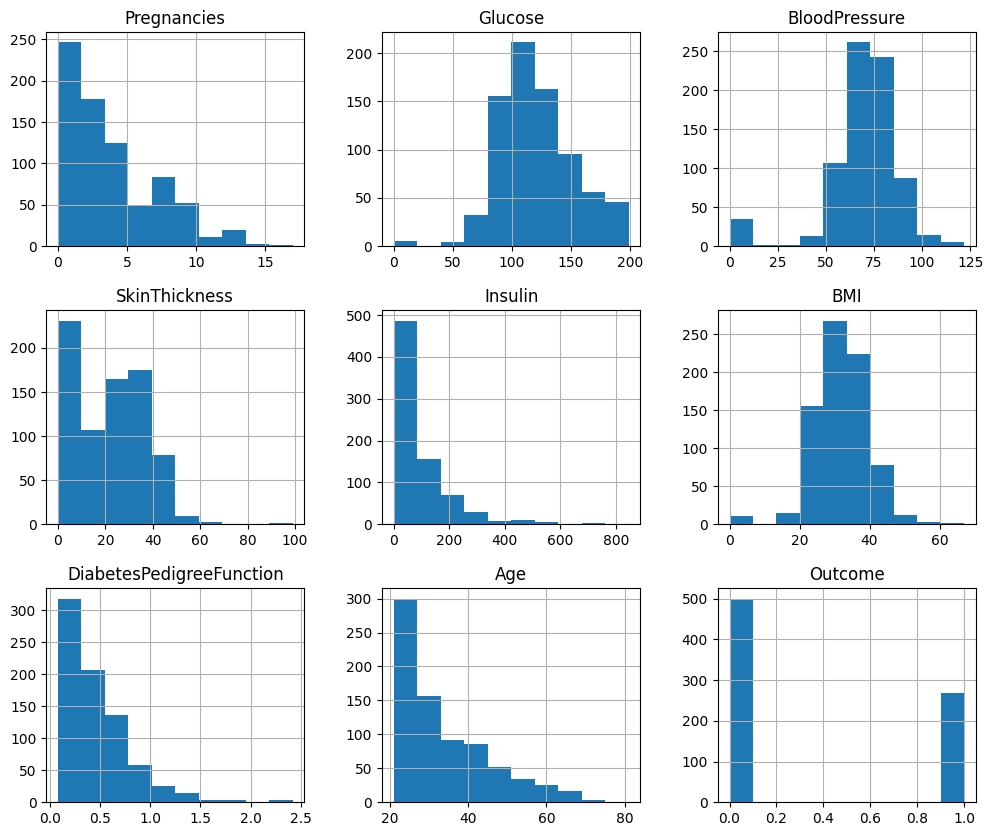

In [26]:
#histogram
df.hist(figsize=(12,10))

plt.show()

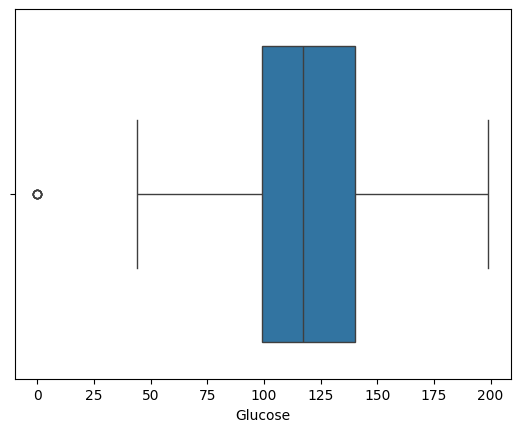

In [27]:
#boxplot
sns.boxplot(x=df["Glucose"])

plt.show()

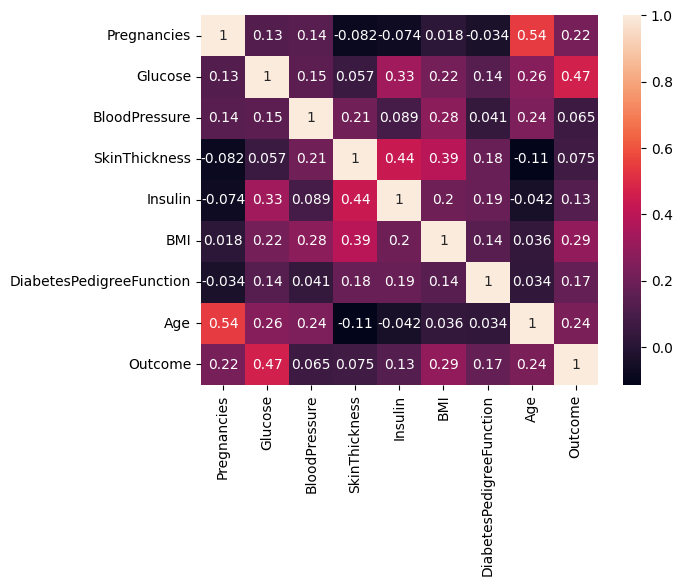

In [28]:
#corelation heatmap
sns.heatmap(df.corr(), annot=True)

plt.show()

In [29]:
# missing values are handled usingimputation technique in which categorical variables are converted into numerical format usung encoding
# hence we replace 0 with median
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for i in cols:

    df[i] = df[i].replace(0, df[i].median())

print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35     30.5  33.6   
1            1       85             66             29     30.5  26.6   
2            8      183             64             23     30.5  23.3   
3            1       89             66             23     94.0  28.1   
4            0      137             40             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


3. Model Building:

a. Build a logistic regression model using appropriate libraries (e.g., scikit-learn).

b. Train the model using the training data.


In [30]:
from sklearn.model_selection import train_test_split

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [31]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

4. Model Evaluation:

a. Evaluate the performance of the model on the testing data using accuracy, precision, recall, F1-score, and ROC-AUC score.

Visualize the ROC curve.


In [32]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred))

Accuracy: 0.7597402597402597
Precision: 0.6730769230769231
Recall: 0.6363636363636364
F1 Score: 0.6542056074766355
ROC AUC Score: 0.7323232323232323


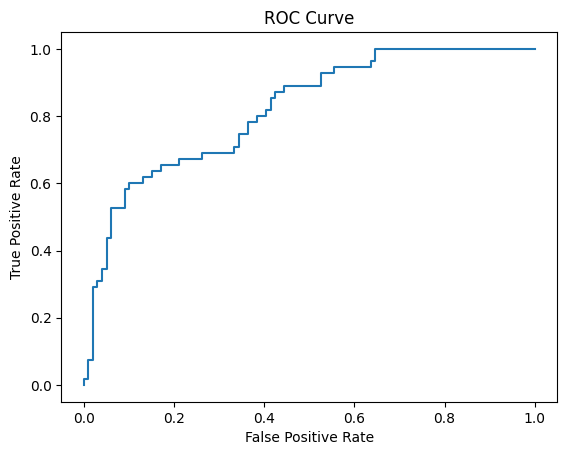

In [33]:
#ROC Curve is used to visualize classification performance
from sklearn.metrics import roc_curve

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, threshold = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()


5. Interpretation:

a. Interpret the coefficients of the logistic regression model.

b. Discuss the significance of features in predicting the target variable (survival probability in this case).


In [34]:
print(model.coef_)
print(model.intercept_)


[[ 0.06619935  0.03854046 -0.01447707  0.00540782 -0.0021911   0.10605128
   0.59013063  0.03334206]]
[-9.51686234]


6. Deployment with Streamlit:

In this task, you will deploy your logistic regression model using Streamlit. The deployment can be done locally or online via Streamlit Share. Your task includes creating a Streamlit app in Python that involves loading your trained model and setting up user inputs for predictions.

https://docs.streamlit.io/streamlit-community-cloud/deploy-your-app


In [35]:
import pickle
pickle.dump(model, open("model.pkl", "wb"))


In [36]:
!pip install streamlit

In [37]:
import streamlit as st
import pickle

model = pickle.load(open("model.pkl", "rb"))

st.title("Diabetes Prediction")
glucose = st.number_input("Enter Glucose : ")
bmi = st.number_input("Enter BMI : ")

if st.button("Predict"):
    prediction = model.predict([[glucose, bmi]])
    st.write("Prediction :", prediction)


2026-06-12 13:23:04.358 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 13:23:04.359 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 13:23:04.360 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 13:23:04.361 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 13:23:04.361 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 13:23:04.362 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 13:23:04.362 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 13:23:04.363 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [39]:
"""
1. What is the difference between precision and recall?
-- precision measures the accuracy of positive predictions wheareas recall measures out of all positive instances how many did the model correctly identify

2. What is cross-validation, and why is it important in binary classification?
-- it is used to evaluate model performance by splitting data into multiple testing and training parts
   its important to reduce overfitting problems and imporves model generalization

"""

'\n1. What is the difference between precision and recall?\n-- precision measures the accuracy of positive predictions wheareas recall measures out of all positive instances how many did the model correctly identify \n \n2. What is cross-validation, and why is it important in binary classification?\n-- it is used to evaluate model performance by splitting data into multiple testing and training parts \n   its important to reduce overfitting problems and imporves model generalization \n\n'